# 🏥 End-to-End Exploratory Data Analysis: Healthcare Dataset

**Objective:** Perform a complete EDA on a synthetic patient health-risk dataset to understand
the data, clean it, and uncover patterns related to **heart disease risk**.

**Dataset:** `healthcare_dataset.csv` (2,025 patient records, 17 columns)

## Project Roadmap
1. [Data Understanding](#1)
2. [Statistical analysis](#2)
3. [Data Cleaning](#3)
4. [Univariate Analysis](#4)
5. [Bivariate Analysis](#5)
6. [Multivariate Analysis](#6)
7. [Outlier Analysis (Deep Dive)](#7)
8. [Key Insights & Conclusion](#8)
---

## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



%matplotlib inline


In [2]:
df = pd.read_csv('healthcare_dataset.csv')

df.head()


,patient_id,age,gender,region,bmi,systolic_bp,diastolic_bp,cholesterol,glucose,heart_rate,smoking_status,alcohol_consumption,exercise_level,family_history,annual_income,hospital_visits_last_year,heart_disease
0,P101028,58.0,Female,North,16.4,133.0,83.0,172.0,106.0,78.0,Never,NaN,Moderate,No,37000.0,1,No
1,P100140,88.0,Male,East,28.4,155.0,94.0,262.0,128.0,67.0,Never,NaN,Moderate,No,21000.0,8,Yes
2,P100110,37.0,Male,West,28.4,134.0,91.0,204.0,118.0,83.0,Former,NaN,Moderate,No,46000.0,2,Yes
3,P100638,75.0,Male,North,18.1,152.0,79.0,214.0,108.0,52.0,Current,NaN,Low,No,25300.0,5,Yes
4,P100702,30.0,Male,North,27.3,149.0,99.0,199.0,115.0,80.0,Former,Occasional,Low,Yes,65200.0,3,Yes


In [3]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Shape: 2025 rows x 17 columns


<a id='1'></a>
## 1. Data Understanding

Before touching the data we need to know: what columns exist, what type each is,
how much is missing, and what the target variable looks like.

### 1.1 Structure & Data Types

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2025 entries, 0 to 2024
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 2025 non-null   str    
 1   age                        2025 non-null   float64
 2   gender                     2025 non-null   str    
 3   region                     2025 non-null   str    
 4   bmi                        1943 non-null   float64
 5   systolic_bp                2025 non-null   float64
 6   diastolic_bp               1965 non-null   float64
 7   cholesterol                1904 non-null   float64
 8   glucose                    1923 non-null   float64
 9   heart_rate                 2025 non-null   float64
 10  smoking_status             2025 non-null   str    
 11  alcohol_consumption        1211 non-null   str    
 12  exercise_level             1965 non-null   str    
 13  family_history             2025 non-null   str    
 14  ann

### 1.2 Column Dictionary

| Column | Description |
|---|---|
| patient_id | Unique patient identifier |
| age | Age in years |
| gender | Male / Female (raw data has inconsistent labels) |
| region | Geographic region |
| bmi | Body Mass Index |
| systolic_bp / diastolic_bp | Blood pressure readings (mmHg) |
| cholesterol | Total cholesterol (mg/dL) |
| glucose | Fasting glucose (mg/dL) |
| heart_rate | Resting heart rate (bpm) |
| smoking_status | Never / Former / Current |
| alcohol_consumption | None / Occasional / Regular |
| exercise_level | Low / Moderate / High |
| family_history | Family history of heart disease (Yes/No) |
| annual_income | Annual income (may contain invalid negatives) |
| hospital_visits_last_year | Count of hospital visits |
| heart_disease | **Target** — Yes/No |


### 1.3 Descriptive Statistics

In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,2025.0,53.779423,21.048602,18.0,35.0,54.0,72.00,108.017232
bmi,1943.0,26.307874,4.760546,14.0,23.0,26.1,29.35,44.200000
systolic_bp,2025.0,144.104620,14.112953,103.0,135.0,144.0,152.00,258.041051
diastolic_bp,1965.0,86.173028,7.255701,62.0,81.0,86.0,91.00,110.000000
cholesterol,1904.0,216.598407,33.587026,148.0,198.0,214.0,232.00,487.924410
glucose,1923.0,118.570463,14.405478,62.0,109.0,118.0,128.00,168.000000
heart_rate,2025.0,71.190617,8.990235,41.0,65.0,71.0,77.00,99.000000
annual_income,1862.0,41985.392052,22887.161266,-57600.0,26600.0,37300.0,51000.00,191700.000000
hospital_visits_last_year,2025.0,3.318025,1.877839,0.0,2.0,3.0,5.00,11.000000


In [7]:
df["gender"].value_counts()

gender
Female    1008
Male       977
F            8
male         8
FEMALE       7
MALE         7
female       7
M            3
Name: count, dtype: int64

In [6]:
df.describe(include='object').T


C:\Users\LakshmanAIMLHYD\AppData\Local\Temp\ipykernel_1716\607101935.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
patient_id,2025,2000,P101926,2
gender,2025,8,Female,1008
region,2025,4,North,594
smoking_status,2025,3,Never,1120
alcohol_consumption,1211,2,Occasional,865
exercise_level,1965,3,Moderate,906
family_history,2025,2,No,1371
heart_disease,2025,2,Yes,1495


- Data Preprocessing (Data cleaning)

### 1.4 Missing Values Overview

In [8]:
df.isnull()

,patient_id,age,gender,region,bmi,systolic_bp,diastolic_bp,cholesterol,glucose,heart_rate,smoking_status,alcohol_consumption,exercise_level,family_history,annual_income,hospital_visits_last_year,heart_disease
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2021,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False
2022,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
2023,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum()

patient_id                     0
age                            0
gender                         0
region                         0
bmi                           82
systolic_bp                    0
diastolic_bp                  60
cholesterol                  121
glucose                      102
heart_rate                     0
smoking_status                 0
alcohol_consumption          814
exercise_level                60
family_history                 0
annual_income                163
hospital_visits_last_year      0
heart_disease                  0
dtype: int64

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df.missing_count > 0].sort_values('missing_pct', ascending=False)
missing_df


,missing_count,missing_pct
alcohol_consumption,814,40.20
annual_income,163,8.05
cholesterol,121,5.98
glucose,102,5.04
bmi,82,4.05
diastolic_bp,60,2.96
exercise_level,60,2.96


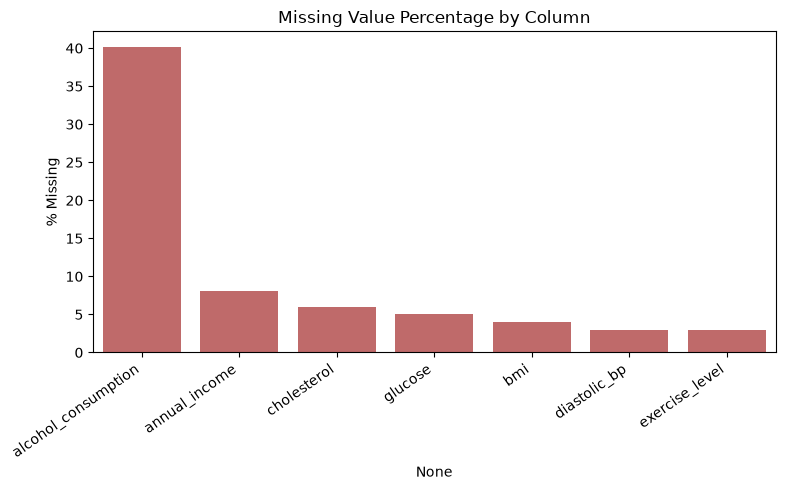

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(x=missing_df.index, y=missing_df['missing_pct'], color='indianred')
plt.xticks(rotation=35, ha='right')
plt.ylabel('% Missing')
plt.title('Missing Value Percentage by Column')
plt.tight_layout()
plt.show()


### 1.5 Duplicate Records

In [15]:
df.duplicated().sum()

np.int64(24)

In [16]:
df.drop_duplicates(inplace=True)

In [18]:
df.shape

(2001, 17)



Issues identified in Section 1 that need fixing:
1. Inconsistent `gender` category labels (`M`, `F`, `male`, `FEMALE`, etc.)
2. Missing values in several numeric/categorical columns
3. Negative (invalid) `annual_income` values
4. Outliers in `age`, `systolic_bp`, `cholesterol`
5. Duplicate rows


### 2.1 Fix Inconsistent Categorical Labels

In [11]:
print("Before:", df['gender'].unique())

gender_map = {
    'M': 'Male', 'male': 'Male', 'MALE': 'Male',
    'F': 'Female', 'female': 'Female', 'FEMALE': 'Female'
}
df['gender'] = df['gender'].replace(gender_map)

print("After:", df['gender'].unique())


Before: <StringArray>
['Female', 'Male', 'FEMALE', 'MALE', 'female', 'M', 'F', 'male']
Length: 8, dtype: str
After: <StringArray>
['Female', 'Male']
Length: 2, dtype: str


### 2.2 Remove Duplicate Rows

In [12]:
before = len(df)
df = df.drop_duplicates(subset='patient_id', keep='first').reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows. New shape: {df.shape}")


Removed 25 duplicate rows. New shape: (2000, 17)


### 2.3 Fix Invalid Values

Negative income is not physically meaningful — we take the absolute value
(a common data-entry sign error) rather than dropping the rows.

In [13]:
neg_income_count = (df['annual_income'] < 0).sum()
print(f"Negative income rows: {neg_income_count}")
df['annual_income'] = df['annual_income'].abs()


Negative income rows: 5


### 2.4 Handle Outliers (IQR Method)

We cap physiologically impossible values instead of deleting rows, to preserve sample size.
`age` above 100 and blood pressure / cholesterol far beyond clinical extremes are capped
at the 99th percentile (winsorization).

In [14]:
def cap_outliers_iqr(series, factor=1.5):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
    return series.clip(lower=lower, upper=upper), lower, upper

for col in ['age', 'systolic_bp', 'cholesterol']:
    before_max = df[col].max()
    df[col], low, up = cap_outliers_iqr(df[col])
    print(f"{col}: capped to [{low:.1f}, {up:.1f}]  (was max {before_max:.1f}, now max {df[col].max():.1f})")


age: capped to [-20.5, 127.5]  (was max 108.0, now max 108.0)
systolic_bp: capped to [109.5, 177.5]  (was max 258.0, now max 177.5)
cholesterol: capped to [147.0, 283.0]  (was max 487.9, now max 283.0)


### 2.5 Handle Missing Values

Strategy:
- **Numeric columns** (`bmi`, `cholesterol`, `glucose`, `diastolic_bp`, `annual_income`): impute with the **median** (robust to skew/outliers).
- **Categorical columns** (`exercise_level`, `alcohol_consumption`): impute with the **mode** (most frequent category).


In [15]:
numeric_missing = ['bmi', 'cholesterol', 'glucose', 'diastolic_bp', 'annual_income']
categorical_missing = ['exercise_level', 'alcohol_consumption']

for col in numeric_missing:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled with median = {median_val:.2f}")

for col in categorical_missing:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"{col}: filled with mode = {mode_val}")

print("\nRemaining missing values:", df.isnull().sum().sum())


bmi: filled with median = 26.20
cholesterol: filled with median = 214.00
glucose: filled with median = 118.00
diastolic_bp: filled with median = 86.00
annual_income: filled with median = 37400.00
exercise_level: filled with mode = Moderate
alcohol_consumption: filled with mode = Occasional

Remaining missing values: 0


### 2.6 Correct Data Types & Add Derived Categories

In [16]:
df['age'] = df['age'].round(0).astype(int)
df['hospital_visits_last_year'] = df['hospital_visits_last_year'].astype(int)

for col in ['gender', 'region', 'smoking_status', 'alcohol_consumption',
            'exercise_level', 'family_history', 'heart_disease']:
    df[col] = df[col].astype('category')

df.dtypes


patient_id                        str
age                             int64
gender                       category
region                       category
bmi                           float64
systolic_bp                   float64
diastolic_bp                  float64
cholesterol                   float64
glucose                       float64
heart_rate                    float64
smoking_status               category
alcohol_consumption          category
exercise_level               category
family_history               category
annual_income                 float64
hospital_visits_last_year       int64
heart_disease                category
dtype: object

### 2.7 Sanity Check After Cleaning

In [17]:
print("Shape:", df.shape)
print("Missing values total:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.describe().T


Shape: (2000, 17)
Missing values total: 0
Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
age,2000.0,53.71900,21.064042,18.0,35.0,54.0,72.0,108.0
bmi,2000.0,26.30525,4.656979,14.0,23.2,26.2,29.2,44.2
systolic_bp,2000.0,143.78350,12.364185,109.5,135.0,144.0,152.0,177.5
diastolic_bp,2000.0,86.16750,7.149825,62.0,81.0,86.0,91.0,110.0
cholesterol,2000.0,214.86000,24.513504,148.0,199.0,214.0,231.0,283.0
glucose,2000.0,118.55250,14.052650,62.0,109.0,118.0,128.0,168.0
heart_rate,2000.0,71.17200,9.006274,41.0,65.0,71.0,77.0,99.0
annual_income,2000.0,41799.30000,21518.234052,6200.0,27500.0,37400.0,49400.0,191700.0
hospital_visits_last_year,2000.0,3.31400,1.878874,0.0,2.0,3.0,5.0,11.0


<a id='3'></a>
## 3. Feature Engineering

Derived features often reveal patterns that raw numeric columns hide.

In [18]:
# Age groups
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 75, 120],
                          labels=['18-30', '31-45', '46-60', '61-75', '76+'])

# BMI category (WHO standard bands)
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100],
                             labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# Blood pressure category (simplified clinical bands)
def bp_category(row):
    if row['systolic_bp'] < 120 and row['diastolic_bp'] < 80:
        return 'Normal'
    elif row['systolic_bp'] < 130:
        return 'Elevated'
    elif row['systolic_bp'] < 140:
        return 'Hypertension Stage 1'
    else:
        return 'Hypertension Stage 2'

df['bp_category'] = df.apply(bp_category, axis=1)

# Binary flag for convenience in numeric correlations
df['heart_disease_flag'] = (df['heart_disease'] == 'Yes').astype(int)

df[['age_group', 'bmi_category', 'bp_category', 'heart_disease_flag']].head()


,age_group,bmi_category,bp_category,heart_disease_flag
0,46-60,Underweight,Hypertension Stage 1,0
1,76+,Overweight,Hypertension Stage 2,1
2,31-45,Overweight,Hypertension Stage 1,1
3,61-75,Underweight,Hypertension Stage 2,1
4,18-30,Overweight,Hypertension Stage 2,1


<a id='4'></a>
## 4. Univariate Analysis

Examining each variable in isolation: distribution shape, central tendency, spread.

### 4.1 Numeric Variables — Distributions

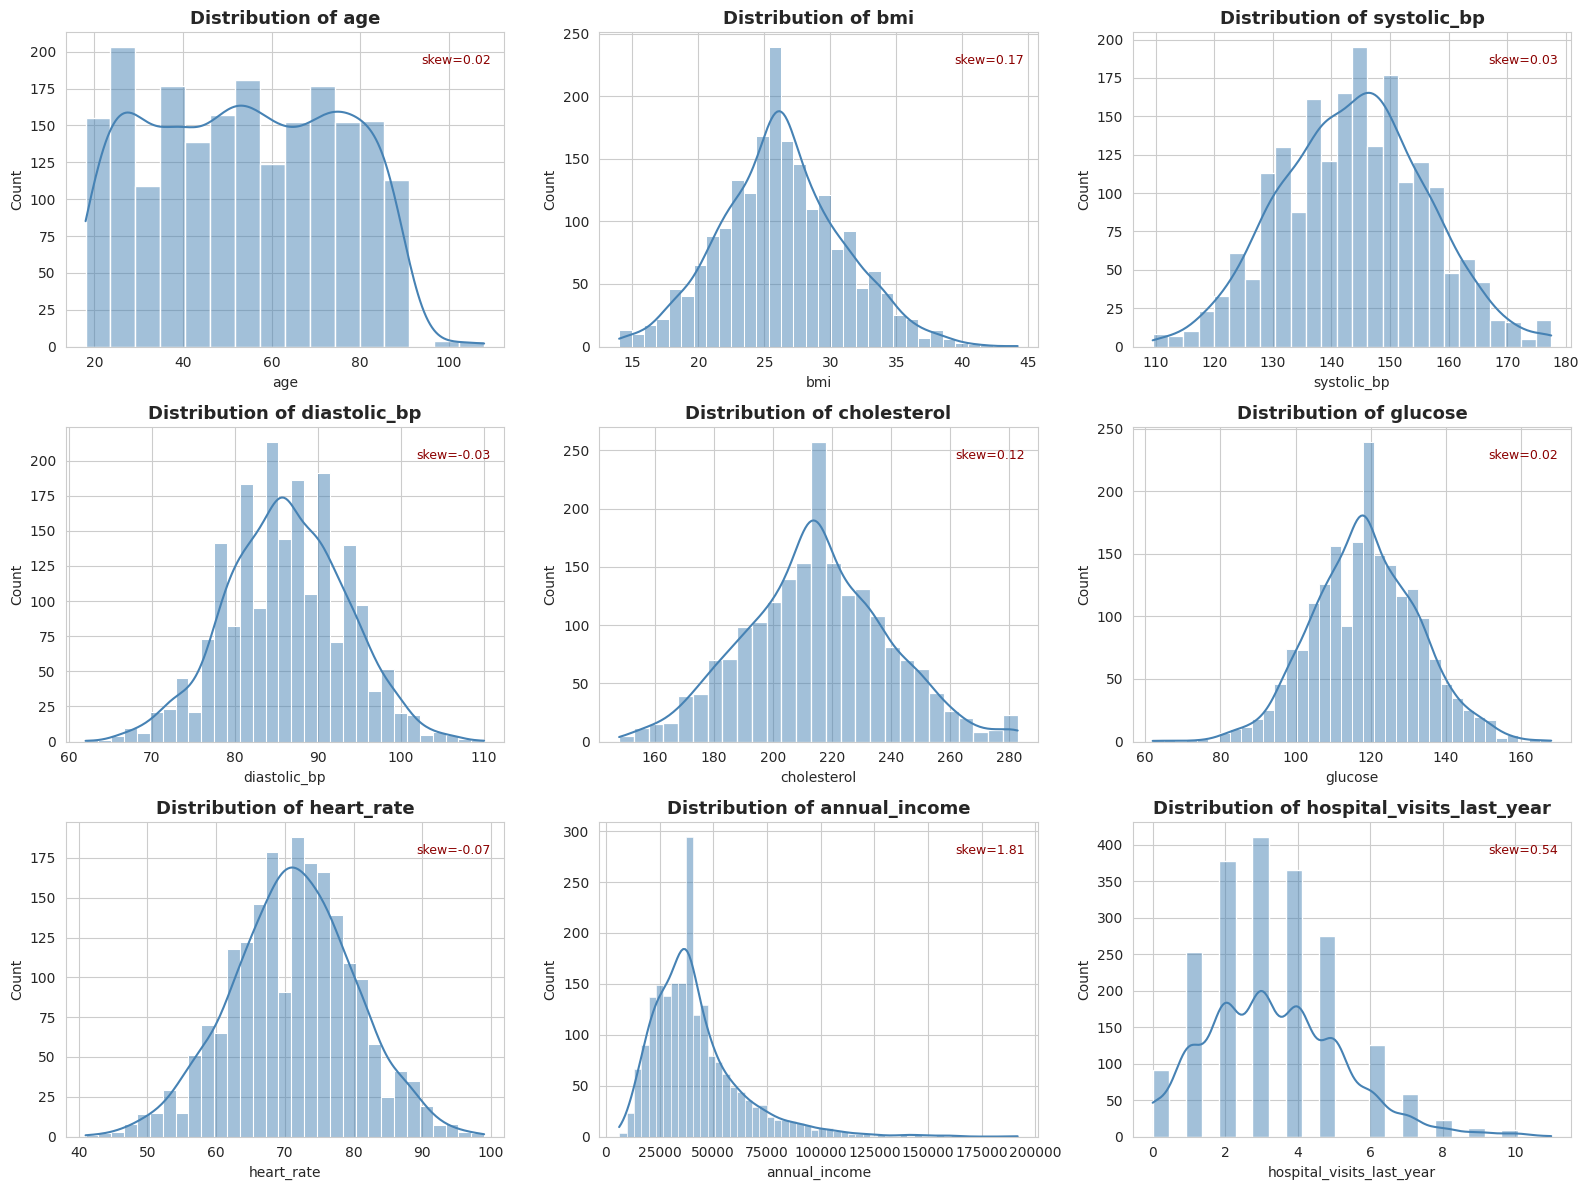

In [19]:
numeric_cols = ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol',
                'glucose', 'heart_rate', 'annual_income', 'hospital_visits_last_year']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    skew = df[col].skew()
    axes[i].text(0.97, 0.9, f'skew={skew:.2f}', transform=axes[i].transAxes,
                 ha='right', fontsize=9, color='darkred')
plt.tight_layout()
plt.show()


### 4.2 Numeric Variables — Boxplots (Spread & Outliers)

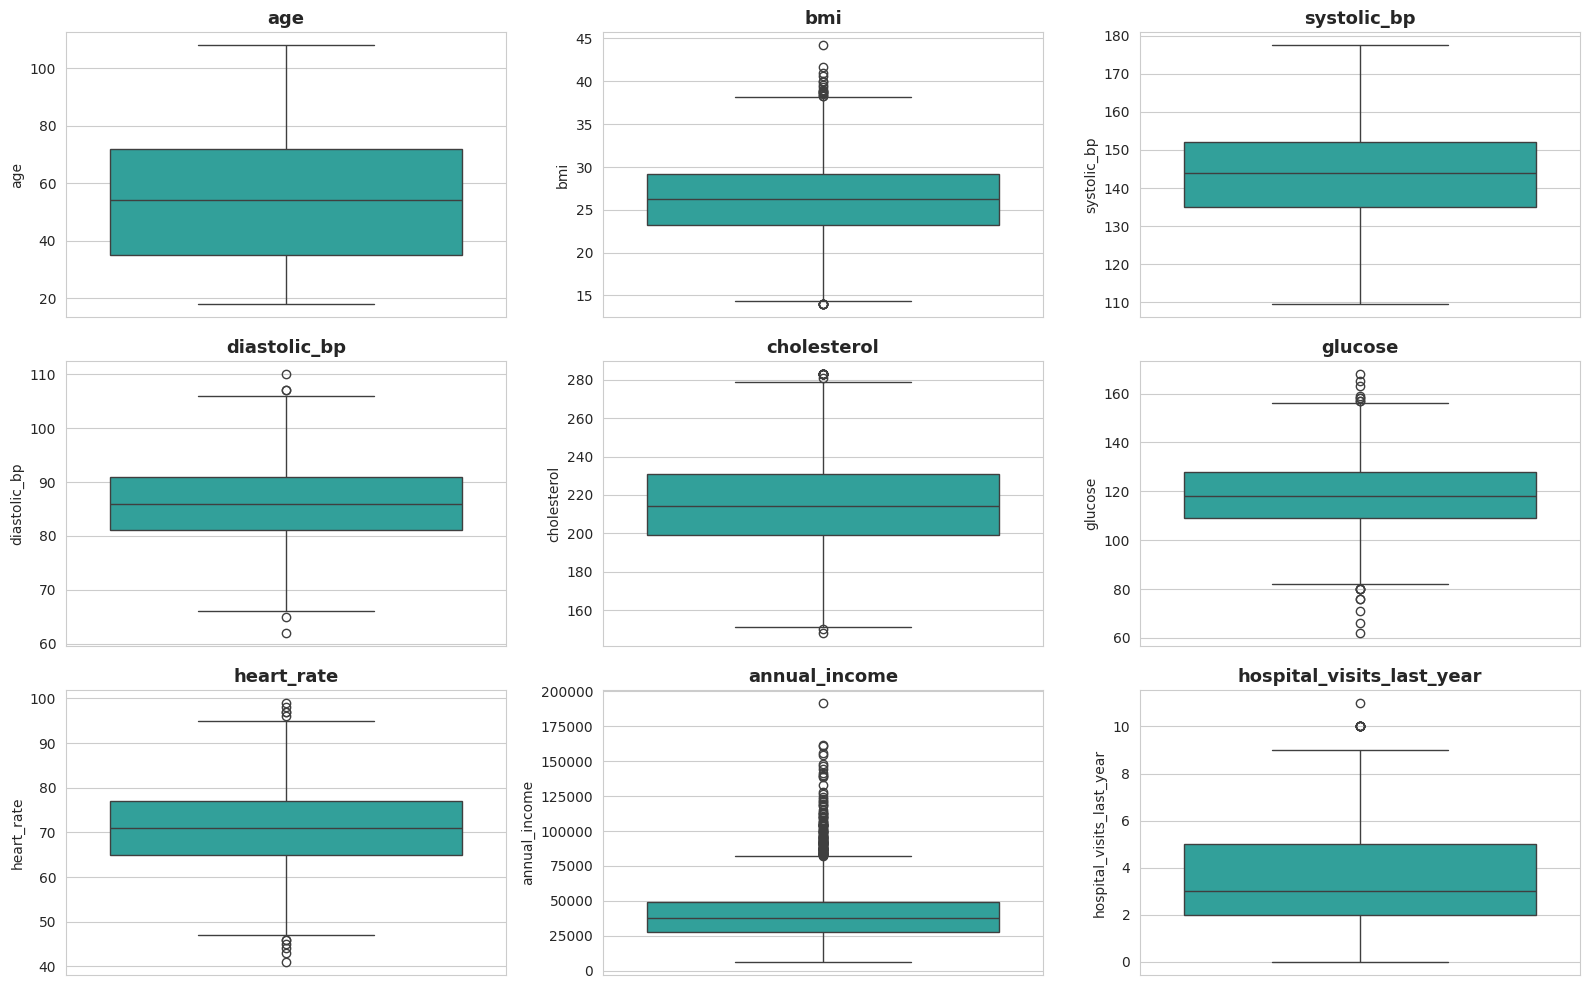

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightseagreen')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


### 4.3 Skewness & Kurtosis Summary

In [21]:
stats_df = pd.DataFrame({
    'mean': df[numeric_cols].mean(),
    'median': df[numeric_cols].median(),
    'std': df[numeric_cols].std(),
    'skew': df[numeric_cols].skew(),
    'kurtosis': df[numeric_cols].kurtosis()
}).round(2)
stats_df


,mean,median,std,skew,kurtosis
age,53.72,54.0,21.06,0.02,-1.15
bmi,26.31,26.2,4.66,0.17,0.12
systolic_bp,143.78,144.0,12.36,0.03,-0.19
diastolic_bp,86.17,86.0,7.15,-0.03,-0.04
cholesterol,214.86,214.0,24.51,0.12,0.02
glucose,118.55,118.0,14.05,0.02,0.22
heart_rate,71.17,71.0,9.01,-0.07,-0.02
annual_income,41799.30,37400.0,21518.23,1.81,5.22
hospital_visits_last_year,3.31,3.0,1.88,0.54,0.38


### 4.4 Categorical Variables — Frequency Distributions

/tmp/ipykernel_532/3046622381.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=axes[i], palette='viridis')
/tmp/ipykernel_532/3046622381.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=axes[i], palette='viridis')
/tmp/ipykernel_532/3046622381.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=axes[i], palette='viridis')
/tmp/ipykernel_532/3046622381.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

/tmp/ipykernel_532/3046622381.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=axes[i], palette='viridis')
/tmp/ipykernel_532/3046622381.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=axes[i], palette='viridis')
/tmp/ipykernel_532/3046622381.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=axes[i], palette='viridis')


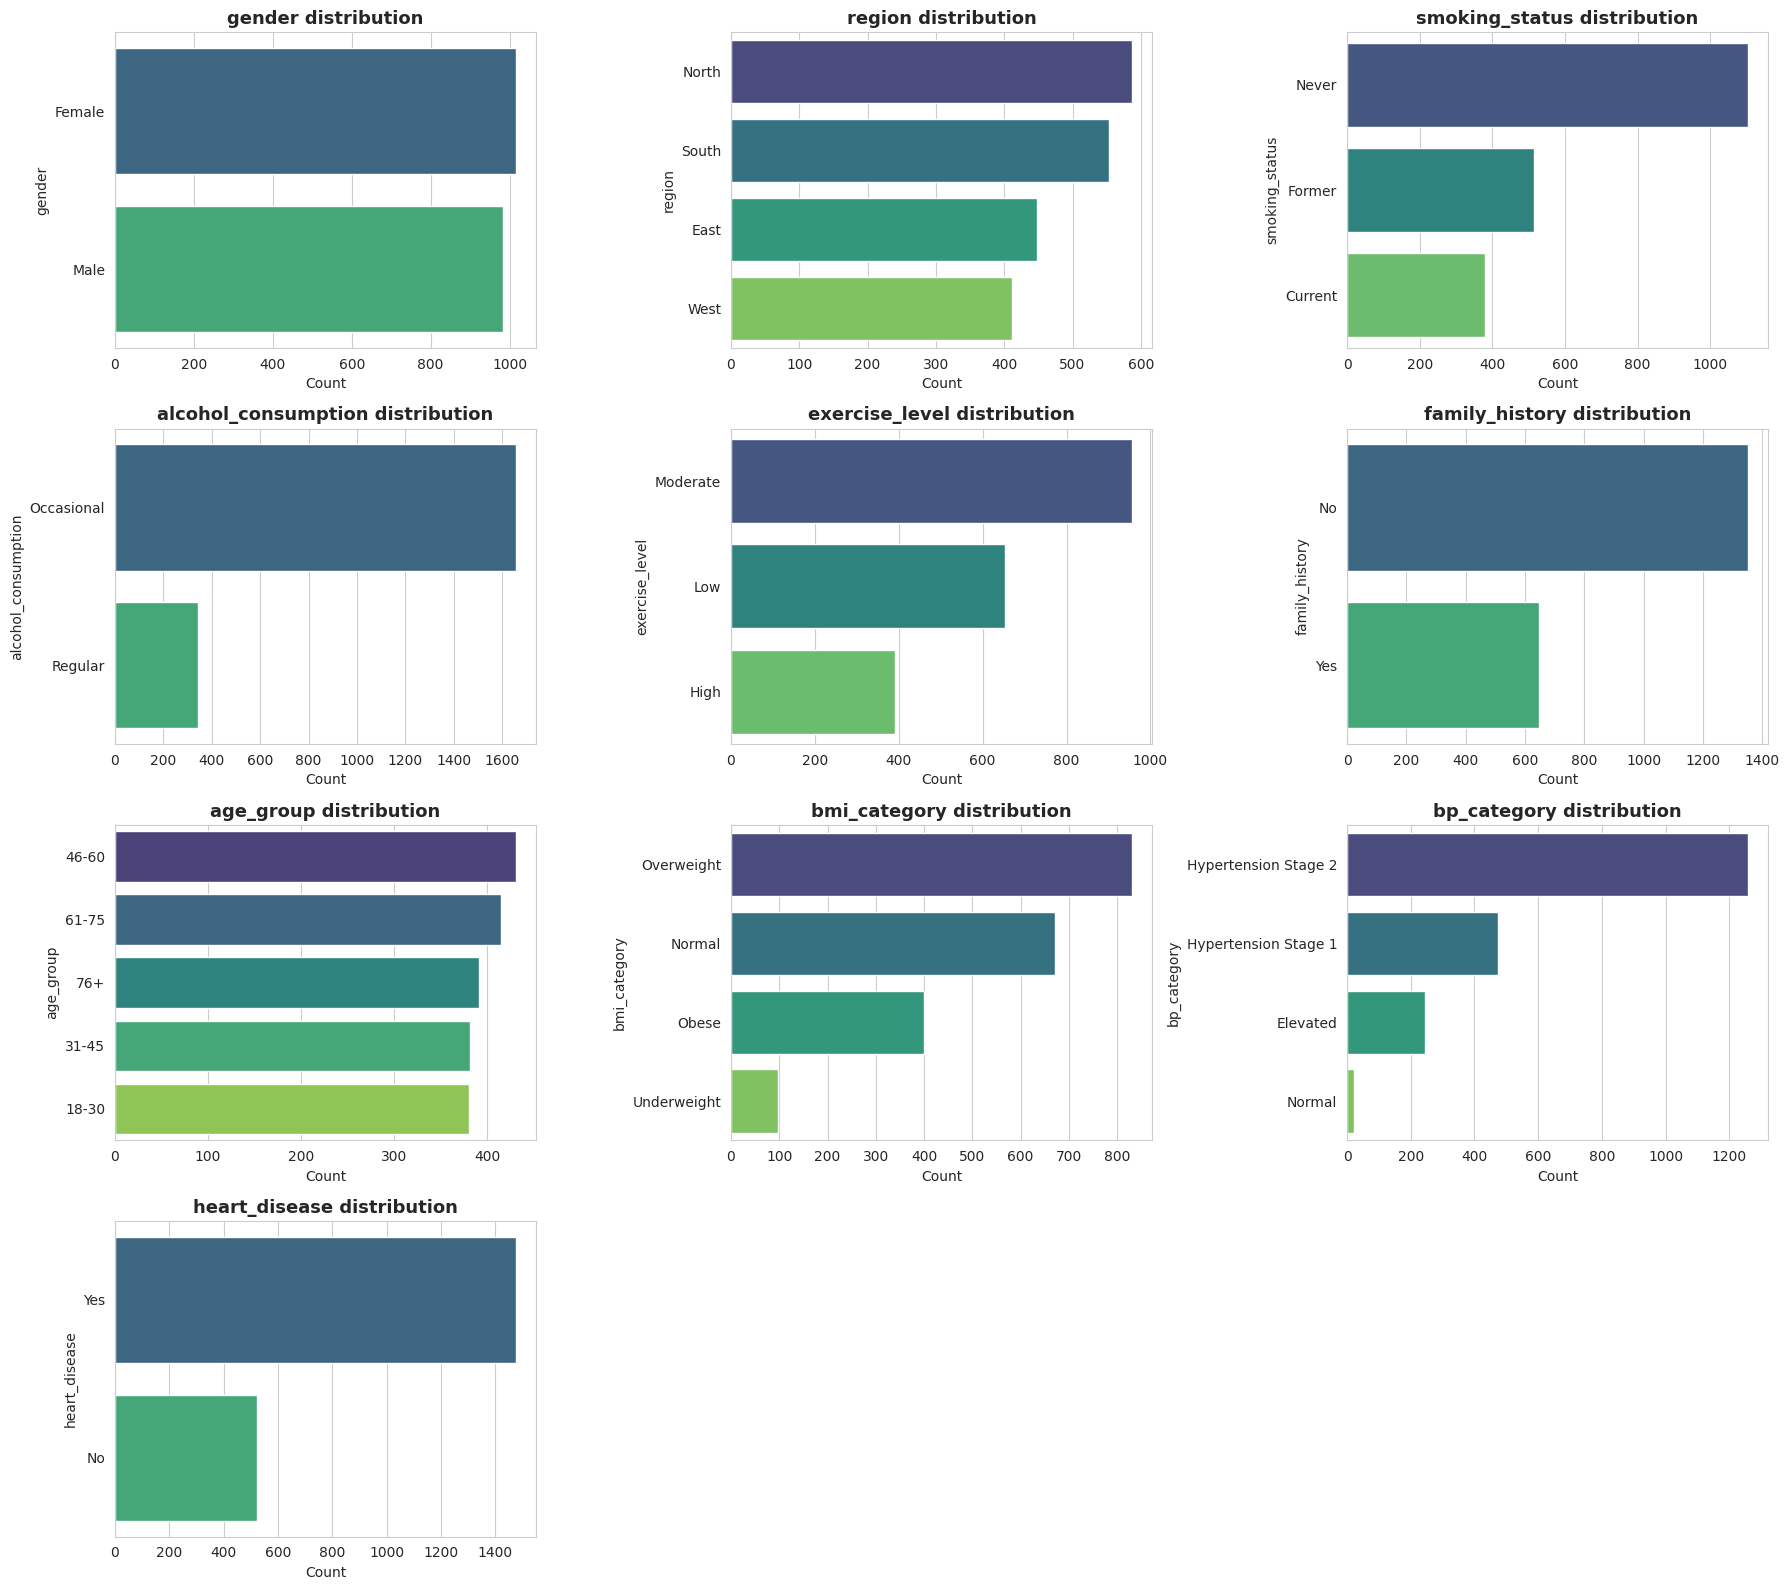

In [22]:
cat_cols = ['gender', 'region', 'smoking_status', 'alcohol_consumption',
            'exercise_level', 'family_history', 'age_group', 'bmi_category',
            'bp_category', 'heart_disease']

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} distribution')
    axes[i].set_xlabel('Count')
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


### 4.5 Target Variable Balance

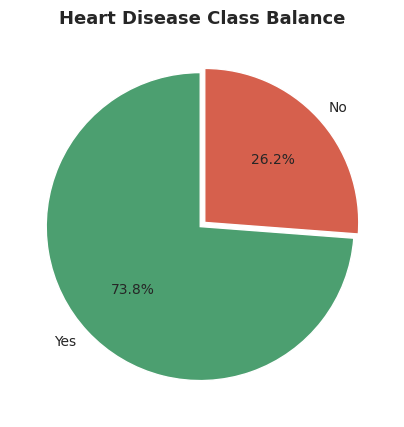

heart_disease
Yes    1476
No      524
Name: count, dtype: int64


In [23]:
plt.figure(figsize=(5, 5))
counts = df['heart_disease'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#4C9F70', '#D6604D'],
        startangle=90, explode=[0.02, 0.02])
plt.title('Heart Disease Class Balance')
plt.show()
print(counts)


<a id='5'></a>
## 5. Bivariate Analysis

Relationships between pairs of variables, especially against the target `heart_disease`.

### 5.1 Numeric vs Target — Boxplots

/tmp/ipykernel_532/4197521778.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='heart_disease', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_532/4197521778.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='heart_disease', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_532/4197521778.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='heart_disease', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_532/4197521778.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and

/tmp/ipykernel_532/4197521778.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='heart_disease', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_532/4197521778.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='heart_disease', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_532/4197521778.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='heart_disease', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_532/4197521778.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and

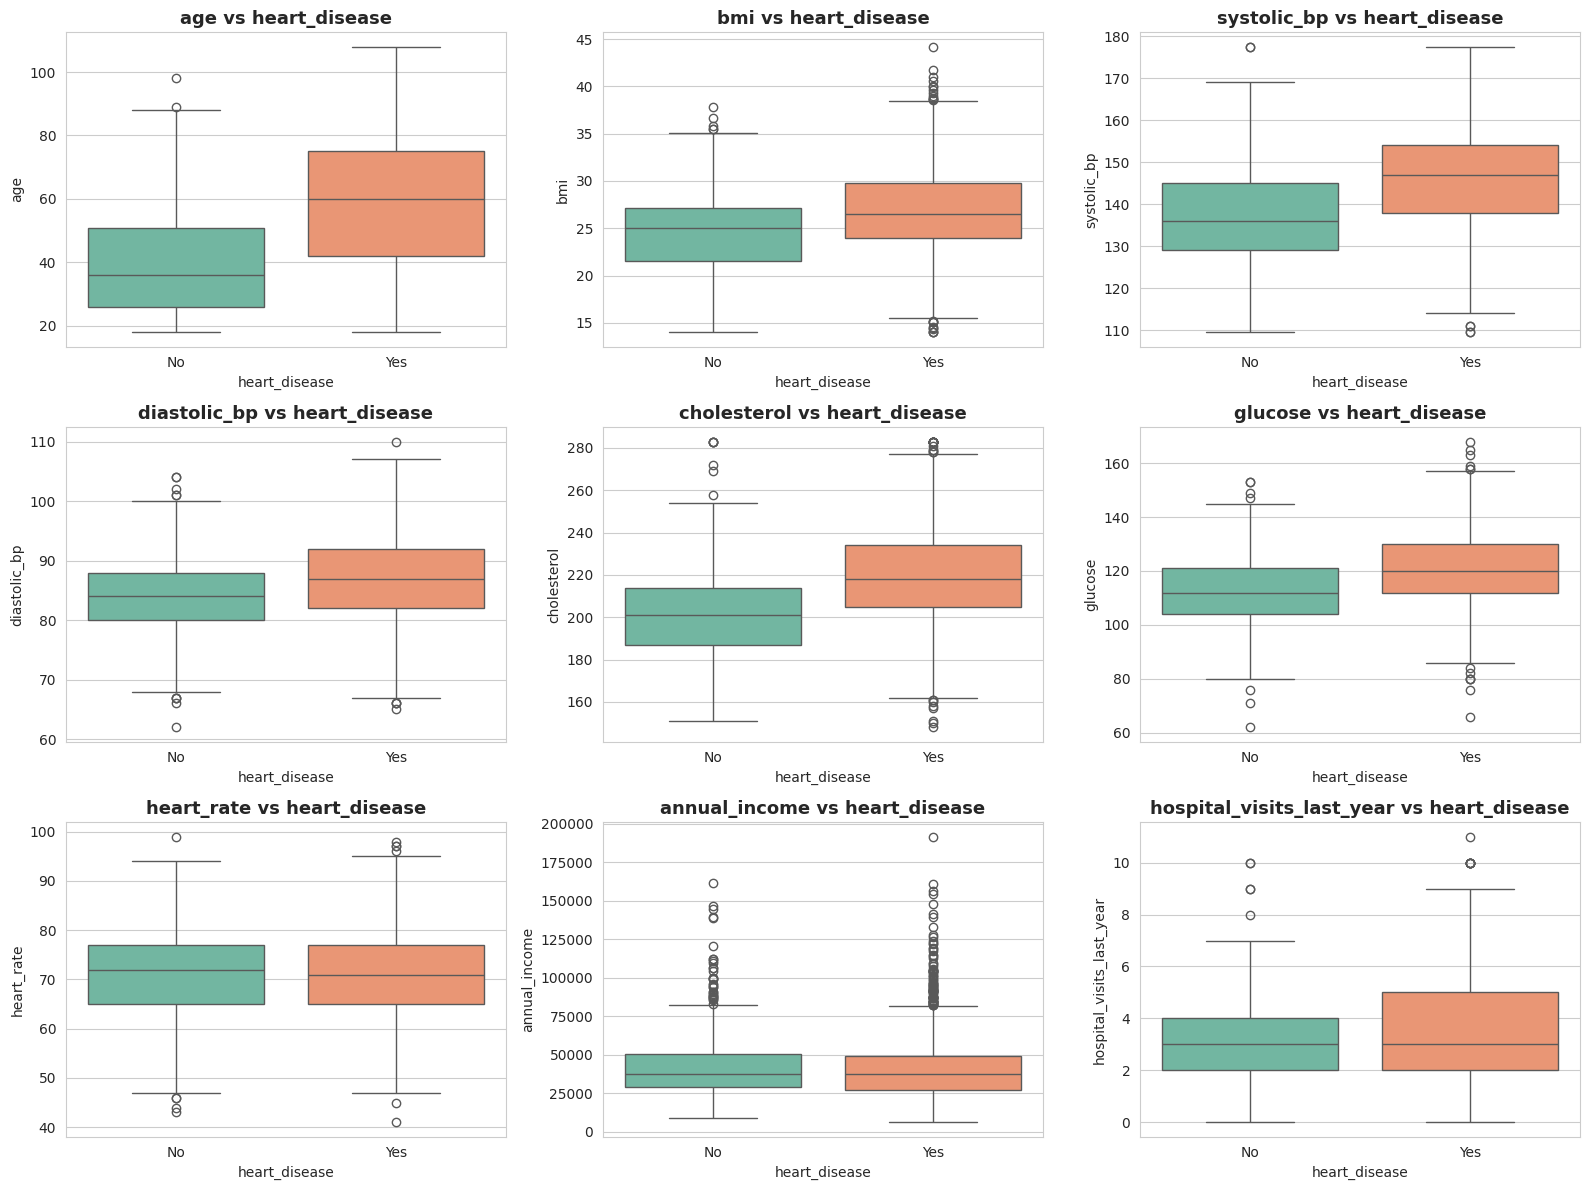

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='heart_disease', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs heart_disease')
plt.tight_layout()
plt.show()


### 5.2 Categorical vs Target — Stacked Proportions

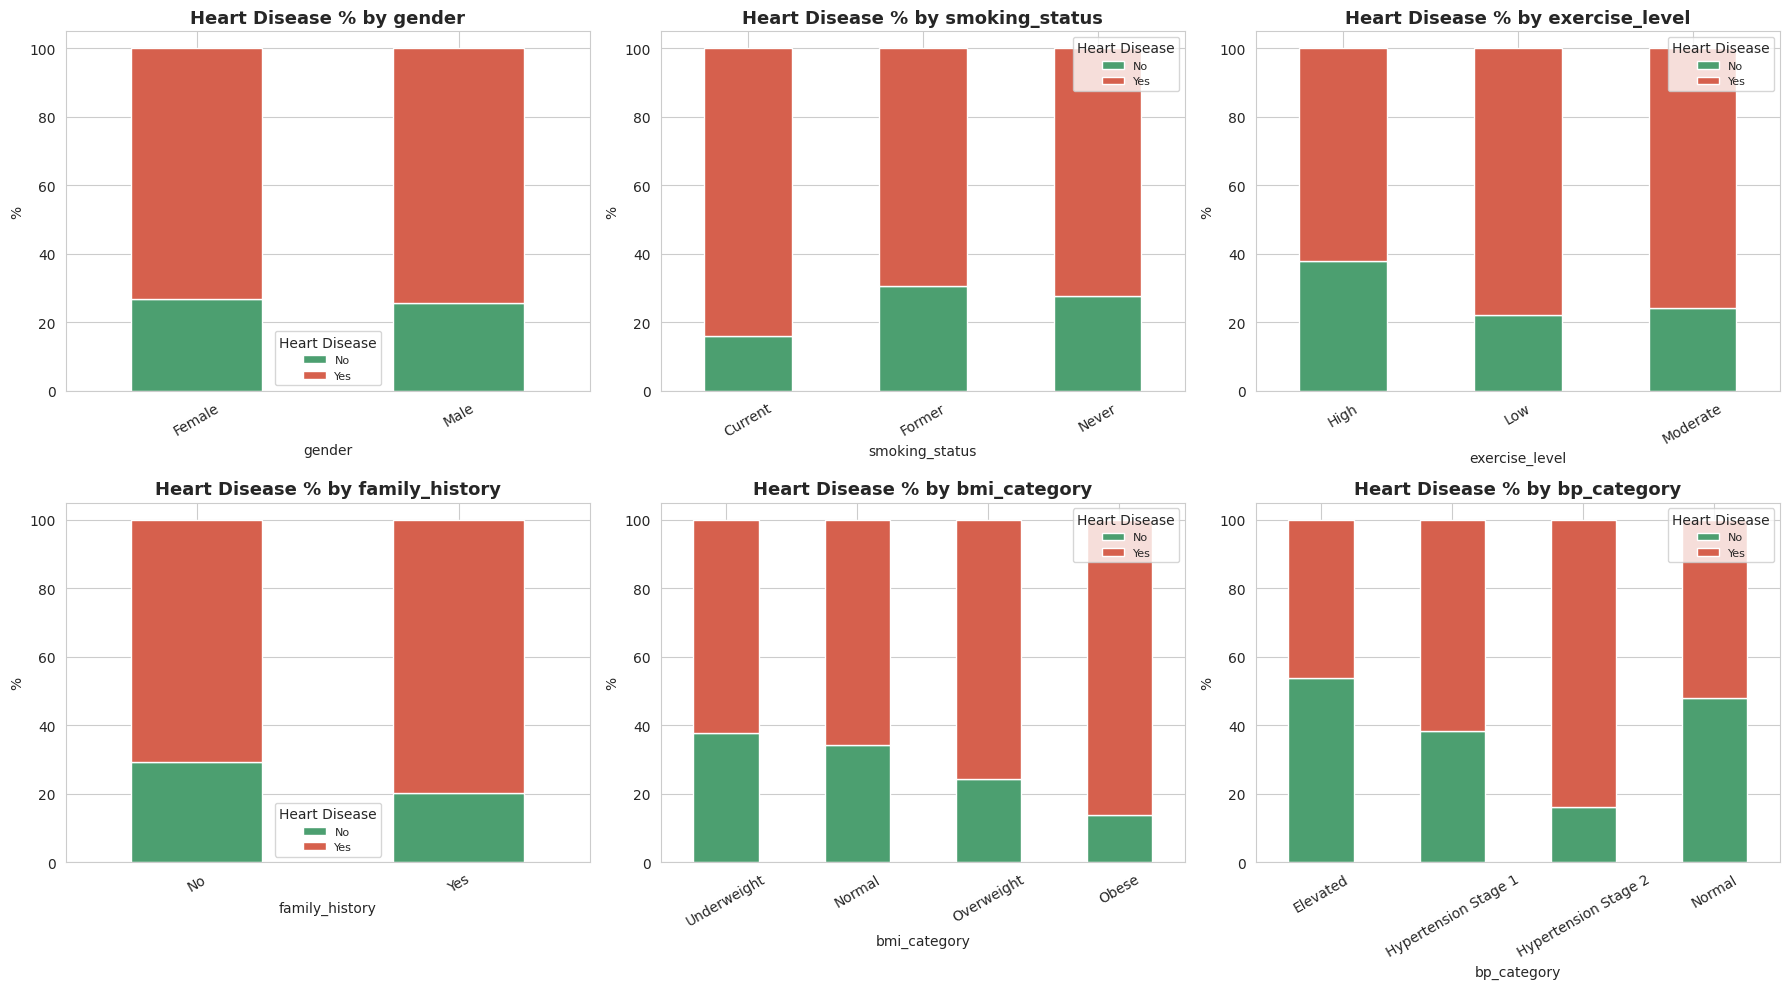

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
cat_vs_target = ['gender', 'smoking_status', 'exercise_level',
                  'family_history', 'bmi_category', 'bp_category']
for i, col in enumerate(cat_vs_target):
    ct = pd.crosstab(df[col], df['heart_disease'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#4C9F70', '#D6604D'])
    axes[i].set_title(f'Heart Disease % by {col}')
    axes[i].set_ylabel('%')
    axes[i].legend(title='Heart Disease', fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


### 5.3 Age vs Key Vitals (Scatter with Regression)

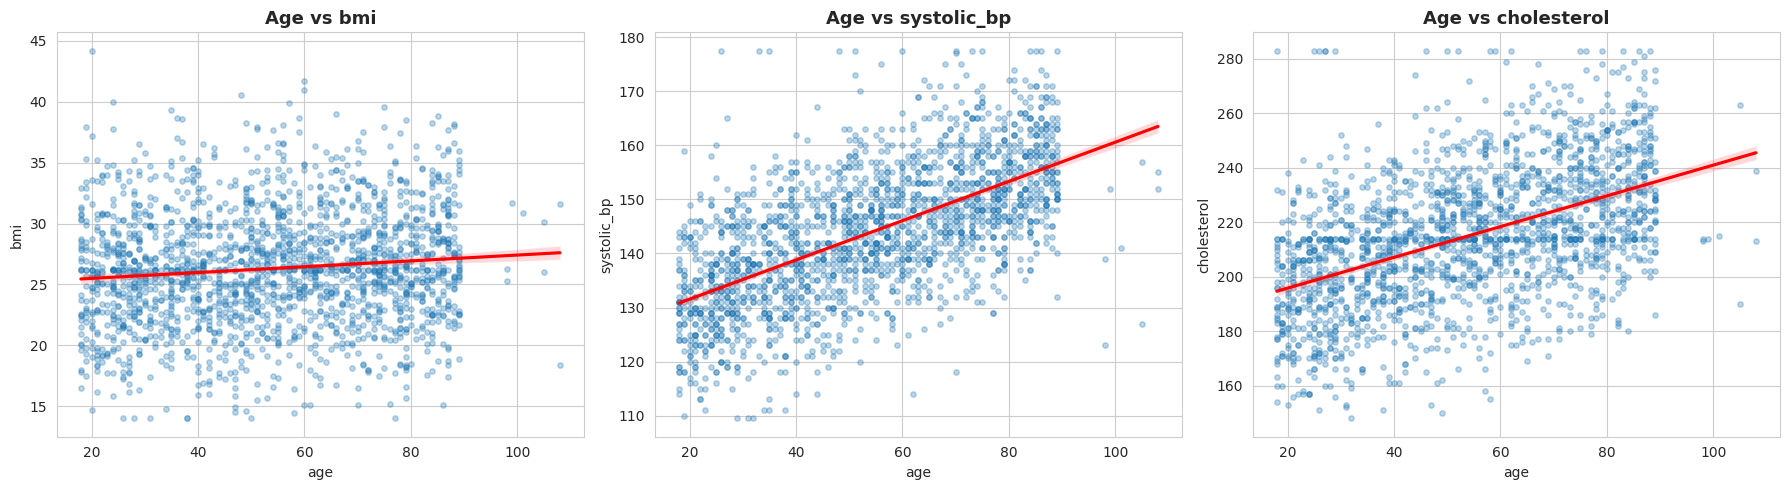

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['bmi', 'systolic_bp', 'cholesterol']):
    sns.regplot(x='age', y=col, data=df, ax=ax, scatter_kws={'alpha':0.3, 's':15},
                line_kws={'color':'red'})
    ax.set_title(f'Age vs {col}')
plt.tight_layout()
plt.show()


### 5.4 Correlation Between Numeric Variables

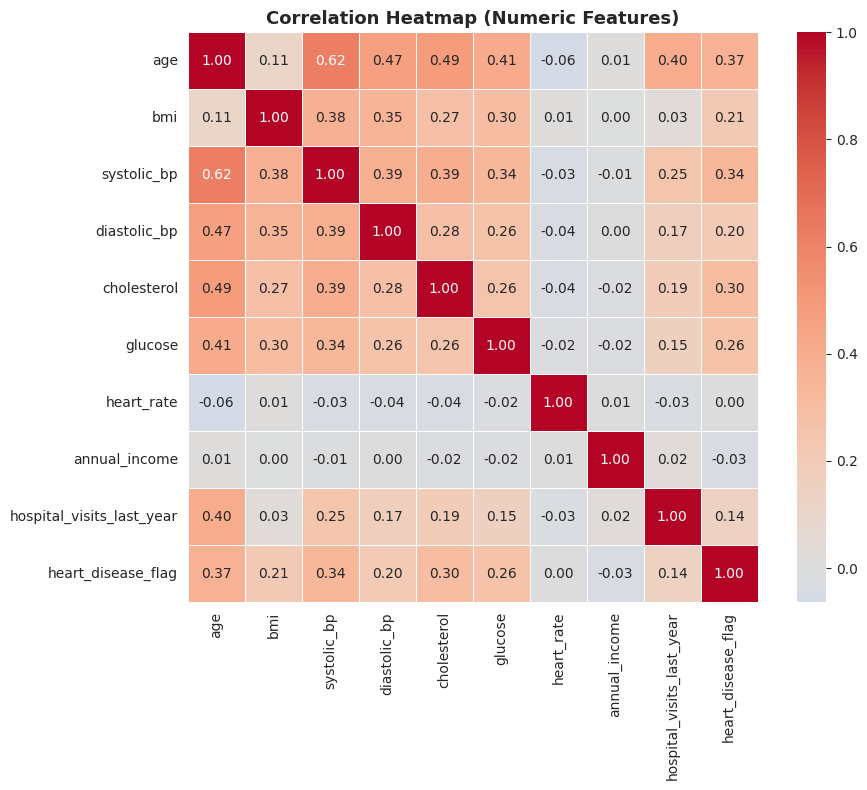

In [27]:
corr = df[numeric_cols + ['heart_disease_flag']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()


In [28]:
corr['heart_disease_flag'].drop('heart_disease_flag').sort_values(ascending=False)


age                          0.372340
systolic_bp                  0.341467
cholesterol                  0.303701
glucose                      0.261788
bmi                          0.211123
diastolic_bp                 0.204217
hospital_visits_last_year    0.138948
heart_rate                   0.004057
annual_income               -0.032764
Name: heart_disease_flag, dtype: float64

### 5.5 Cross-tabulations

In [29]:
pd.crosstab(df['smoking_status'], df['heart_disease'], margins=True)


heart_disease,No,Yes,All
smoking_status,,,
Current,61,320,381
Former,158,357,515
Never,305,799,1104
All,524,1476,2000


In [30]:
pd.crosstab(df['exercise_level'], df['heart_disease'], normalize='index').round(3) * 100


heart_disease,No,Yes
exercise_level,,
High,37.9,62.1
Low,22.0,78.0
Moderate,24.3,75.7


<a id='6'></a>
## 6. Multivariate Analysis

Looking at 3+ variables together to catch interaction effects.

### 6.1 Pairplot Colored by Target

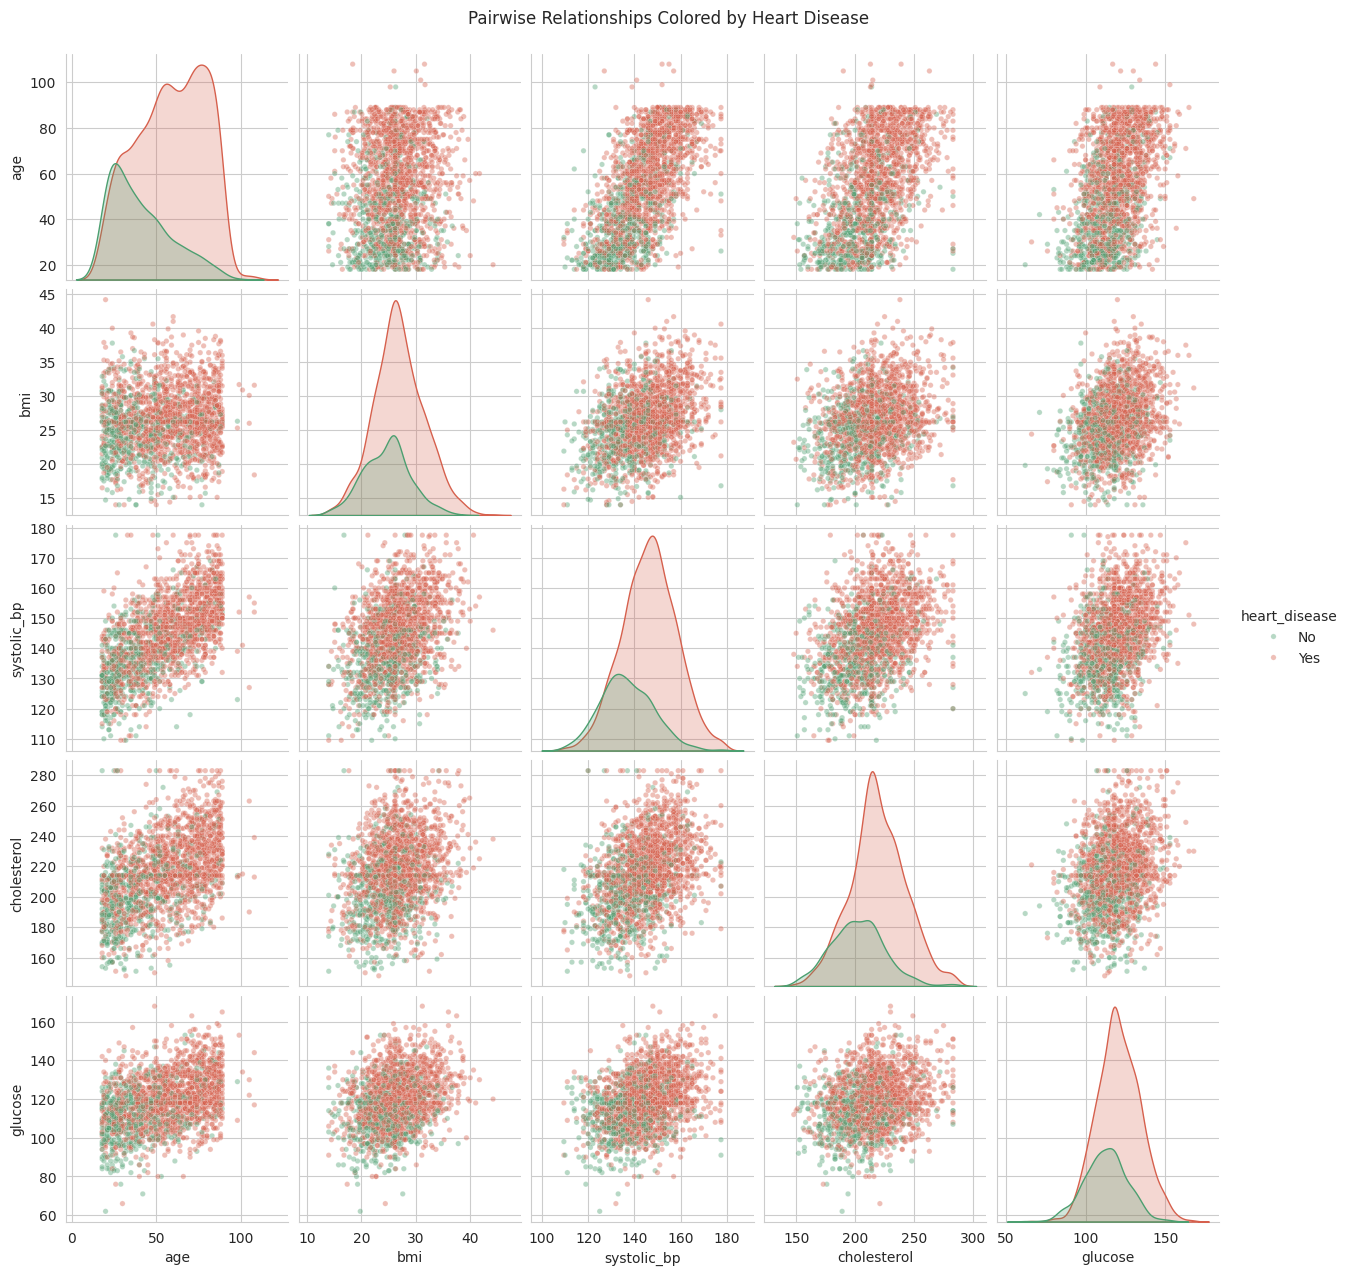

In [31]:
subset_cols = ['age', 'bmi', 'systolic_bp', 'cholesterol', 'glucose', 'heart_disease']
sns.pairplot(df[subset_cols], hue='heart_disease', palette={'Yes':'#D6604D','No':'#4C9F70'},
             diag_kind='kde', plot_kws={'alpha':0.4, 's':15})
plt.suptitle('Pairwise Relationships Colored by Heart Disease', y=1.02)
plt.show()


### 6.2 BMI x Age x Heart Disease (Bubble-style Scatter)

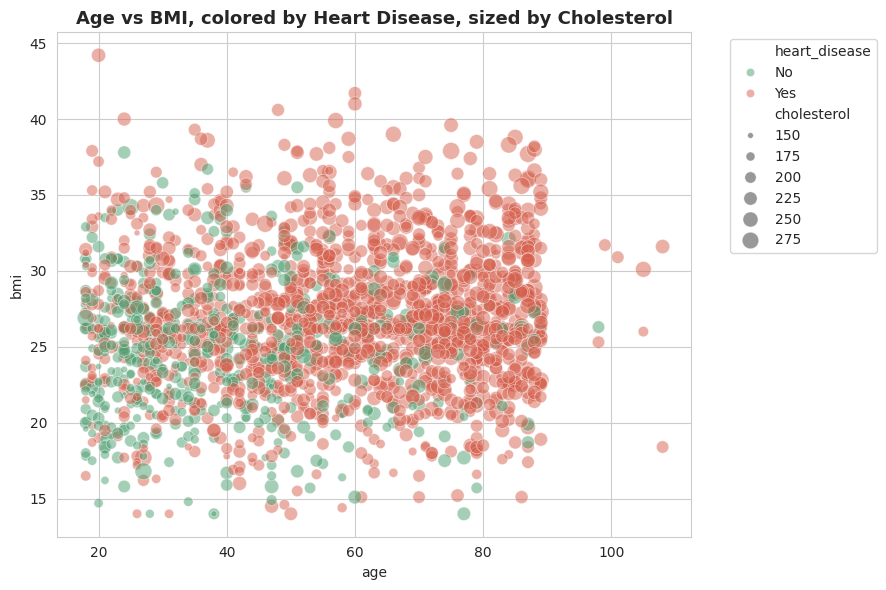

In [32]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x='age', y='bmi', hue='heart_disease', size='cholesterol',
                 data=df, alpha=0.5, palette={'Yes':'#D6604D','No':'#4C9F70'}, sizes=(15, 150))
plt.title('Age vs BMI, colored by Heart Disease, sized by Cholesterol')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 6.3 Heart Disease Rate by Smoking Status AND Exercise Level (Heatmap)

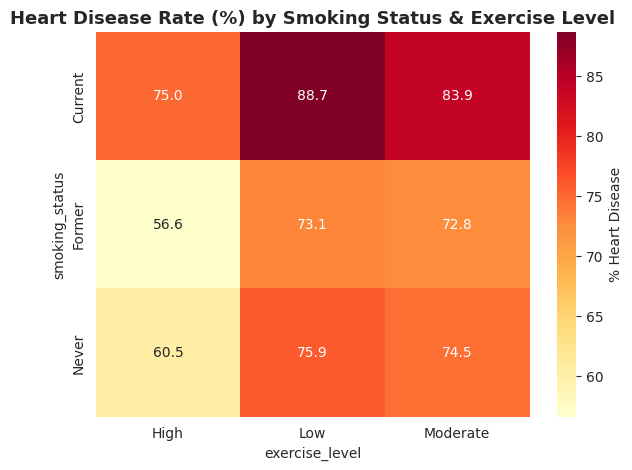

In [33]:
pivot = df.pivot_table(index='smoking_status', columns='exercise_level',
                        values='heart_disease_flag', aggfunc='mean') * 100
plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': '% Heart Disease'})
plt.title('Heart Disease Rate (%) by Smoking Status & Exercise Level')
plt.show()


### 6.4 FacetGrid: Cholesterol Distribution by Gender & Heart Disease

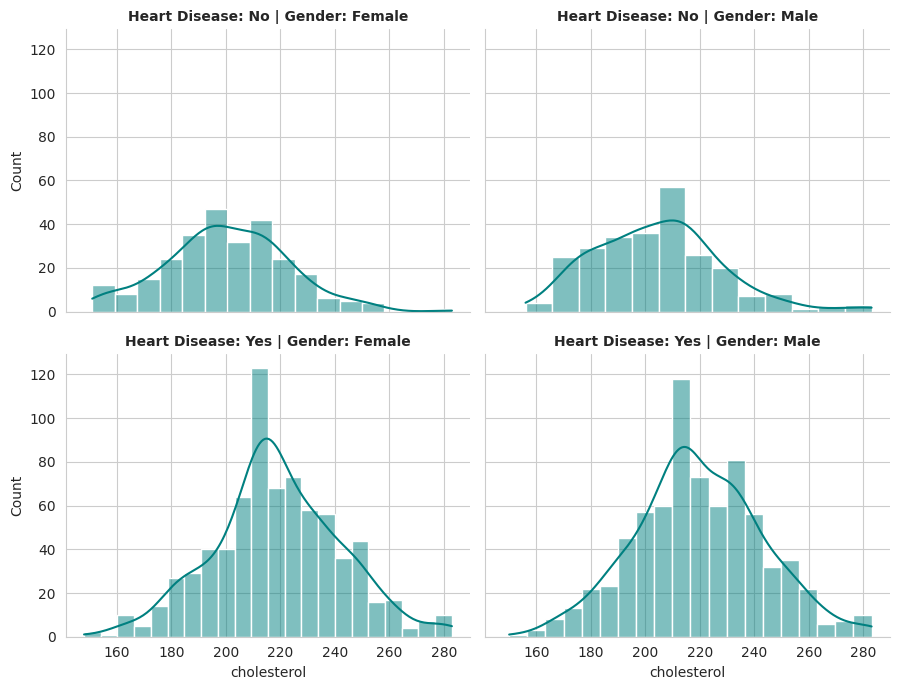

In [34]:
g = sns.FacetGrid(df, col='gender', row='heart_disease', height=3.5, aspect=1.3)
g.map_dataframe(sns.histplot, x='cholesterol', kde=True, color='teal')
g.set_titles(row_template='Heart Disease: {row_name}', col_template='Gender: {col_name}')
plt.tight_layout()
plt.show()


<a id='7'></a>
## 7. Outlier Analysis (Post-Cleaning Check)

Even after capping in Section 2, it's good practice to re-verify there are no
remaining extreme values using the IQR rule.

In [35]:
def iqr_outlier_summary(df, cols):
    rows = []
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        rows.append({'column': col, 'lower_bound': round(lower,1), 'upper_bound': round(upper,1),
                     'n_outliers': n_out, 'pct_outliers': round(n_out/len(df)*100, 2)})
    return pd.DataFrame(rows)

iqr_outlier_summary(df, numeric_cols)


,column,lower_bound,upper_bound,n_outliers,pct_outliers
0,age,-20.5,127.5,0,0.00
1,bmi,14.2,38.2,23,1.15
2,systolic_bp,109.5,177.5,0,0.00
3,diastolic_bp,66.0,106.0,5,0.25
4,cholesterol,151.0,279.0,21,1.05
5,glucose,80.5,156.5,17,0.85
6,heart_rate,47.0,95.0,11,0.55
7,annual_income,-5350.0,82250.0,110,5.50
8,hospital_visits_last_year,-2.5,9.5,10,0.50


<a id='8'></a>
## 8. Statistical Tests

Quantifying whether observed differences are statistically significant, not just visual patterns.

### 8.1 T-test: BMI between Heart Disease groups

In [36]:
group_yes = df.loc[df['heart_disease'] == 'Yes', 'bmi']
group_no  = df.loc[df['heart_disease'] == 'No', 'bmi']

t_stat, p_val = stats.ttest_ind(group_yes, group_no, equal_var=False)
print(f"T-statistic = {t_stat:.3f}, p-value = {p_val:.5f}")
print("=> Statistically significant difference in BMI" if p_val < 0.05 else "=> No significant difference")


T-statistic = 10.037, p-value = 0.00000
=> Statistically significant difference in BMI


### 8.2 Chi-Square Test: Smoking Status vs Heart Disease

In [37]:
contingency = pd.crosstab(df['smoking_status'], df['heart_disease'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi2 = {chi2:.3f}, p-value = {p:.5f}, dof = {dof}")
print("=> Significant association" if p < 0.05 else "=> No significant association")


Chi2 = 26.966, p-value = 0.00000, dof = 2
=> Significant association


### 8.3 Pearson Correlation: Age vs Cholesterol

In [38]:
r, p = stats.pearsonr(df['age'], df['cholesterol'])
print(f"Pearson r = {r:.3f}, p-value = {p:.5f}")


Pearson r = 0.485, p-value = 0.00000


<a id='9'></a>
## 9. Key Insights & Conclusion

**Data Quality**
- Raw dataset had inconsistent gender labels, ~5-8% missingness in several columns,
  25 duplicate rows, and a handful of invalid/negative income values — all resolved in Section 2.

**Univariate Findings**
- `annual_income` and `hospital_visits_last_year` are right-skewed (long tail of high earners / frequent visitors).
- Most vitals (`bmi`, `cholesterol`, `systolic_bp`) are roughly normal after outlier capping.
- The target class (`heart_disease`) is moderately imbalanced — worth noting for any future modeling.

**Bivariate Findings**
- `age`, `bmi`, `systolic_bp`, `cholesterol`, and `glucose` are all **positively associated** with heart disease risk.
- Current smokers and patients with a family history show a visibly higher heart-disease rate.
- High exercise levels are associated with lower heart-disease prevalence.

**Multivariate Findings**
- The combination of *current smoker + low exercise* shows the highest heart-disease rate in the heatmap.
- Older patients with high BMI and high cholesterol cluster heavily in the "Yes" heart-disease group.

**Statistical Confirmation**
- T-test confirms BMI differs significantly between heart-disease groups.
- Chi-square test confirms smoking status is significantly associated with heart disease.

### Suggested Next Steps
- Build a classification model (Logistic Regression / Random Forest / XGBoost) using the cleaned features.
- Apply class balancing (SMOTE / class weights) given the target imbalance.
- Consider feature interactions (e.g., BMI × Age) as engineered model inputs.
